# 05 — Explicabilité du modèle (SHAP)

On analyse **pourquoi** le modèle prédit ce qu'il prédit, à deux niveaux :
- **Global** : quelles features comptent le plus sur l'ensemble des clients ?
- **Local** : pourquoi ce score pour un client précis ?

On utilise **SHAP** : pour chaque prédiction, il calcule la contribution de chaque feature au résultat final.

## 1. Imports et configuration

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import mlflow
import warnings
warnings.filterwarnings('ignore')

shap.initjs()

# dossier de sortie pour les graphiques SHAP
SHAP_DIR = '../outputs/shap'
os.makedirs(SHAP_DIR, exist_ok=True)

print(f"SHAP version : {shap.__version__}")
print(f"Dossier de sortie : {SHAP_DIR}")

SHAP version : 0.51.0
Dossier de sortie : ../outputs/shap


## 2. Chargement des données et du modèle

In [2]:
# Chargement du dataset preprocessé
df = pd.read_csv('../data/processed/dataset_final.csv')

# Séparation features / cible (identique au notebook 03/04)
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Nettoyage des noms de colonnes (même traitement que notebook 03)
import re
X.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X.columns]

print(f"Dataset chargé : {X.shape[0]} clients, {X.shape[1]} features")
print(f"Taux de défaut : {y.mean():.2%}")

Dataset chargé : 307511 clients, 209 features
Taux de défaut : 8.07%


In [3]:
mlflow.set_tracking_uri("../mlruns")

model_uri = "models:/scoring-credit-lgbm/2"

try:
    lgbm_model = mlflow.lightgbm.load_model(model_uri)
    print(f"Modèle chargé : {model_uri}")
    print(f"Type : {type(lgbm_model)}")
except Exception as e:
    print(f"Erreur : {e}")

Modèle chargé : models:/scoring-credit-lgbm/2
Type : <class 'lightgbm.sklearn.LGBMClassifier'>


## 3. Explicabilité globale

### 3.1 Feature importance LightGBM (gain)

Le "gain" mesure combien chaque feature réduit l'erreur en moyenne à chaque split dans les arbres. Plus c'est élevé, plus la feature est décisive.

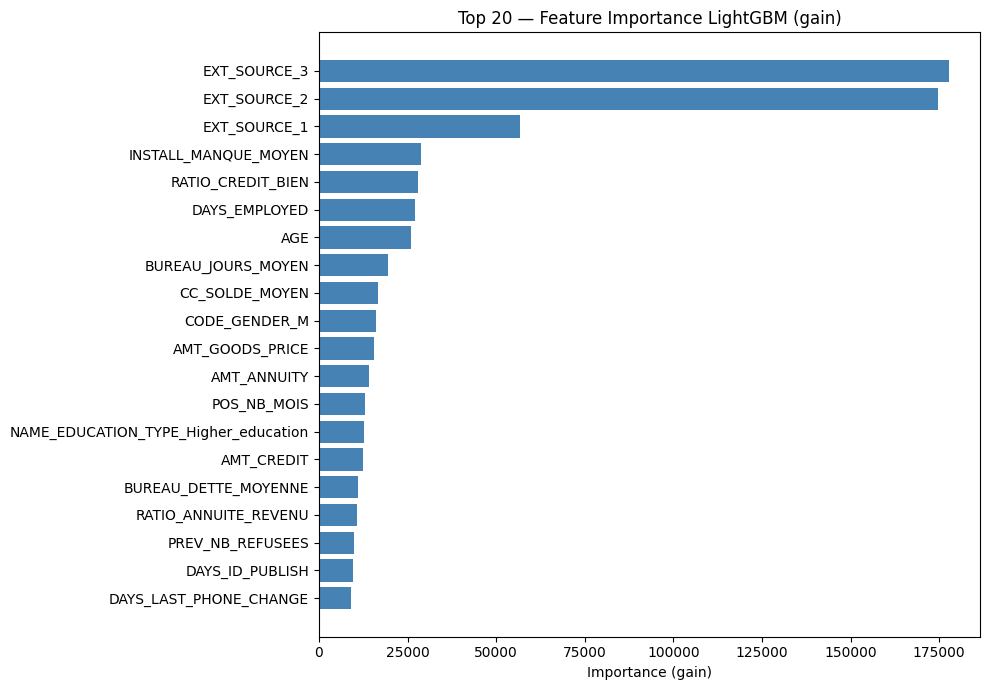


Top 10 features :
             feature    importance
        EXT_SOURCE_3 177660.193658
        EXT_SOURCE_2 174799.175766
        EXT_SOURCE_1  56619.177318
INSTALL_MANQUE_MOYEN  28672.588696
   RATIO_CREDIT_BIEN  27871.349024
       DAYS_EMPLOYED  27238.057113
                 AGE  26068.358566
  BUREAU_JOURS_MOYEN  19540.772845
      CC_SOLDE_MOYEN  16697.617533
       CODE_GENDER_M  16150.705551


In [4]:
booster = lgbm_model.booster_

feature_names = booster.feature_name()
importances = booster.feature_importance(importance_type='gain')

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top20 = fi_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 20 — Feature Importance LightGBM (gain)')
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/feature_importance_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features :")
print(fi_df.head(10).to_string(index=False))

**Analyse :** `EXT_SOURCE_3` et `EXT_SOURCE_2` dominent très largement — ce sont les scores de crédit externes, déjà identifiés comme les variables les plus corrélées à TARGET dans l'EDA. `INSTALL_MANQUE_MOYEN` (retards de paiement passés sur les crédits en cours) et `RATIO_CREDIT_BIEN` arrivent ensuite — cohérent avec la logique métier. `AGE` et `DAYS_EMPLOYED` confirment que l'ancienneté et l'âge jouent aussi un rôle.

### 3.2 SHAP — Importance globale et direction des effets

La feature importance native ne dit pas dans quel sens une variable influence la prédiction. SHAP calcule pour chaque client la contribution réelle de chaque feature : une valeur SHAP positive pousse vers "défaut", négative pousse vers "bon client".

On travaille sur un échantillon de 5000 clients (le calcul serait trop long sur 300k).

In [5]:
from sklearn.model_selection import train_test_split

# échantillon stratifié : conserve le ratio 8%/92%
_, X_sample, _, y_sample = train_test_split(
    X, y, test_size=5000, stratify=y, random_state=42
)

print(f"Échantillon : {X_sample.shape[0]} clients, taux défaut : {y_sample.mean():.2%}")

# TreeExplainer est optimisé pour les modèles à base d'arbres
explainer = shap.TreeExplainer(lgbm_model)

print("Calcul SHAP en cours...")
shap_values = explainer.shap_values(X_sample)
print(f"Shape : {np.array(shap_values).shape}")

Échantillon : 5000 clients, taux défaut : 8.08%
Calcul SHAP en cours...
Shape : (5000, 209)


### 3.3 SHAP Summary Plot (global)

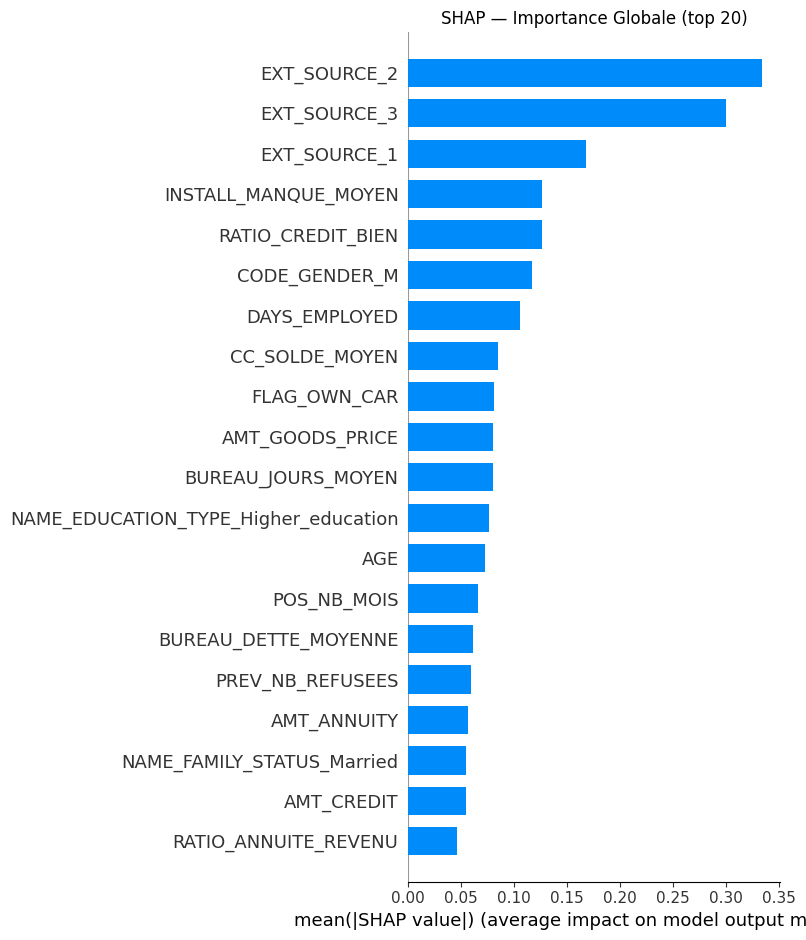

In [6]:
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(sv, X_sample, plot_type='bar', max_display=20, show=False)
plt.title("SHAP — Importance Globale (top 20)")
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/shap_importance_globale.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Beeswarm — direction des effets

Chaque point = un client. Position horizontale = valeur SHAP. Couleur = valeur réelle de la feature (rouge = haute, bleu = basse).

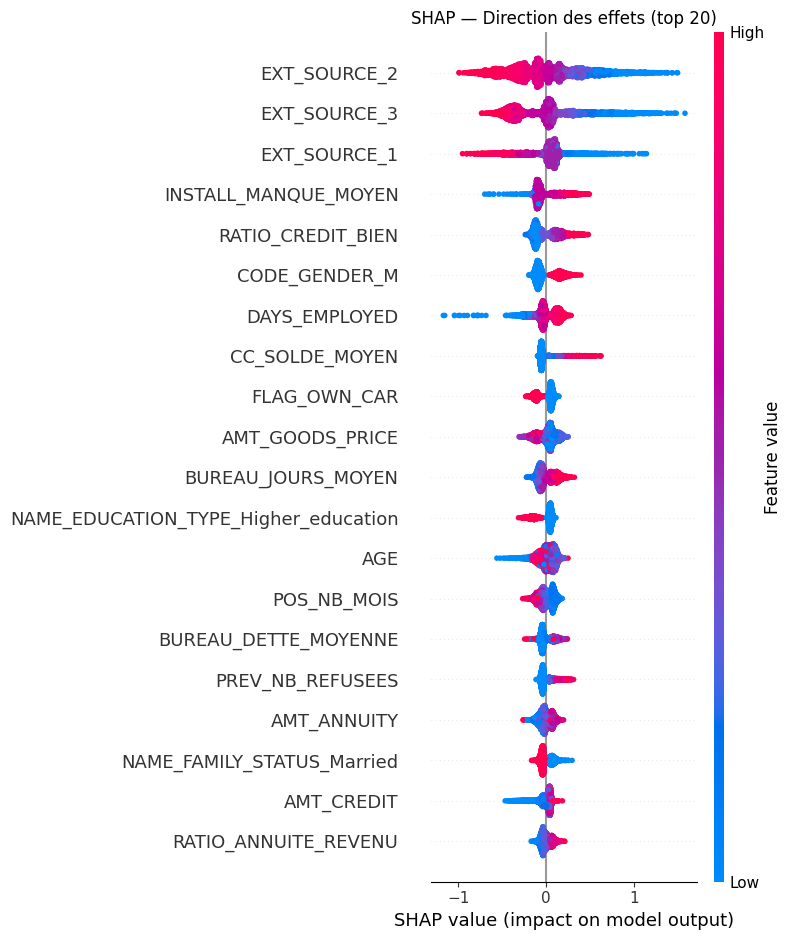

In [7]:
plt.figure()
shap.summary_plot(sv, X_sample, plot_type='dot', max_display=20, show=False)
plt.title("SHAP — Direction des effets (top 20)")
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse :** Pour `EXT_SOURCE_2` et `EXT_SOURCE_3` : les points rouges (score élevé) sont à gauche → SHAP négatif → réduit le risque. Les points bleus (score faible) sont à droite → SHAP positif → augmente le risque. La relation est claire et logique. Pour `DAYS_EMPLOYED` : les points rouges (valeur haute = client salarié depuis peu) poussent vers le défaut — les jeunes salariés sont plus risqués.

## 4. Explicabilité locale — un client précis

On explique la prédiction pour deux clients : un bon payeur (proba défaut = 0.021) et un client en défaut (proba = 0.928). Le waterfall plot décompose la prédiction : on part de la valeur de base (prédiction moyenne sur tout le dataset) et chaque feature tire vers le haut ou vers le bas.

### 4.1 Sélection des clients

In [8]:
# predict_proba retourne [proba_classe_0, proba_classe_1] → on prend la colonne 1
probas = lgbm_model.predict_proba(X_sample)[:, 1]

X_sample_eval = X_sample.copy()
X_sample_eval['proba_defaut'] = probas
X_sample_eval['TARGET'] = y_sample.values

# client avec la plus faible proba de défaut (TARGET=0)
clients_bon = X_sample_eval[X_sample_eval['TARGET'] == 0].sort_values('proba_defaut')
idx_bon = clients_bon.index[0]

# client avec la plus haute proba de défaut (TARGET=1)
clients_defaut = X_sample_eval[X_sample_eval['TARGET'] == 1].sort_values('proba_defaut', ascending=False)
idx_defaut = clients_defaut.index[0]

print(f"Client A (bon payeur) — proba défaut : {X_sample_eval.loc[idx_bon, 'proba_defaut']:.4f}")
print(f"Client B (défaut)     — proba défaut : {X_sample_eval.loc[idx_defaut, 'proba_defaut']:.4f}")

Client A (bon payeur) — proba défaut : 0.0211
Client B (défaut)     — proba défaut : 0.9277


### 4.2 Waterfall plots

=== Client A — Bon payeur ===


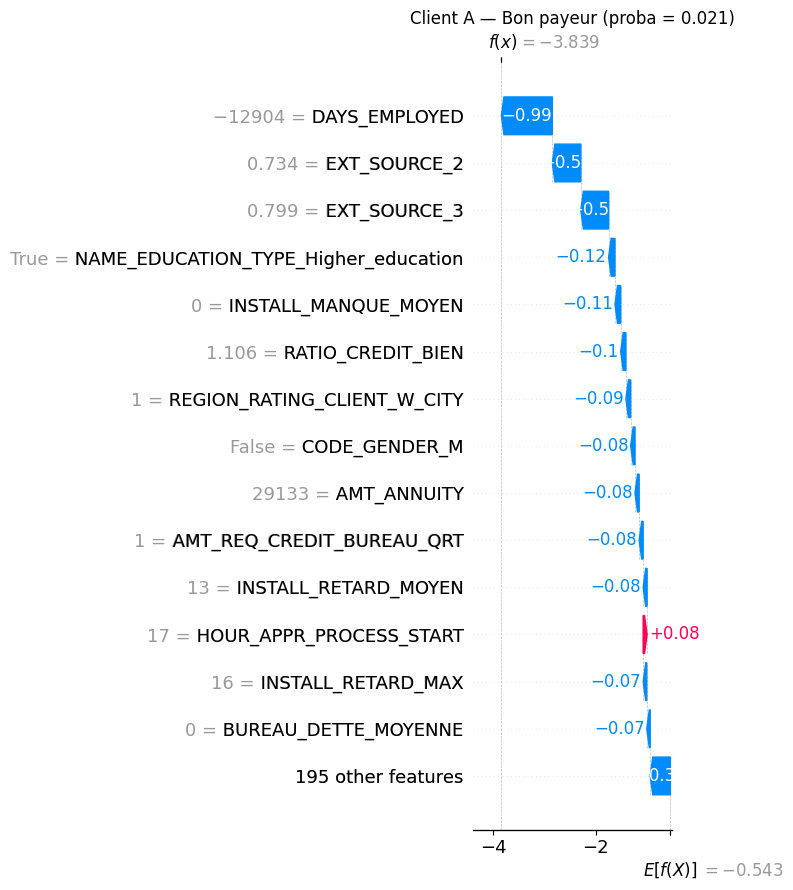

In [9]:
sample_indices = list(X_sample.index)
pos_bon    = sample_indices.index(idx_bon)
pos_defaut = sample_indices.index(idx_defaut)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[-1]

exp_bon = shap.Explanation(
    values=sv[pos_bon],
    base_values=expected_value,
    data=X_sample.iloc[pos_bon].values,
    feature_names=list(X_sample.columns)
)
exp_defaut = shap.Explanation(
    values=sv[pos_defaut],
    base_values=expected_value,
    data=X_sample.iloc[pos_defaut].values,
    feature_names=list(X_sample.columns)
)

print("=== Client A — Bon payeur ===")
plt.figure()
shap.waterfall_plot(exp_bon, max_display=15, show=False)
plt.title(f"Client A — Bon payeur (proba = {X_sample_eval.loc[idx_bon, 'proba_defaut']:.3f})")
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/shap_waterfall_bon.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse Client A (proba = 0.021) :** Le plus fort contributeur est `DAYS_EMPLOYED = -12904` (≈ 35 ans d'ancienneté) avec un SHAP de -0.99 — une stabilité professionnelle exceptionnelle qui rassure fortement le modèle. 

`EXT_SOURCE_2` (0.734) et `EXT_SOURCE_3` (0.799) ajoutent chacun ~-0.5. 

La seule note légèrement négative est `HOUR_APPR_PROCESS_START` (+0.08), sans impact réel. 

Au total, f(x) = -3.839 en log-odds → proba défaut très faible.

=== Client B — Défaut ===


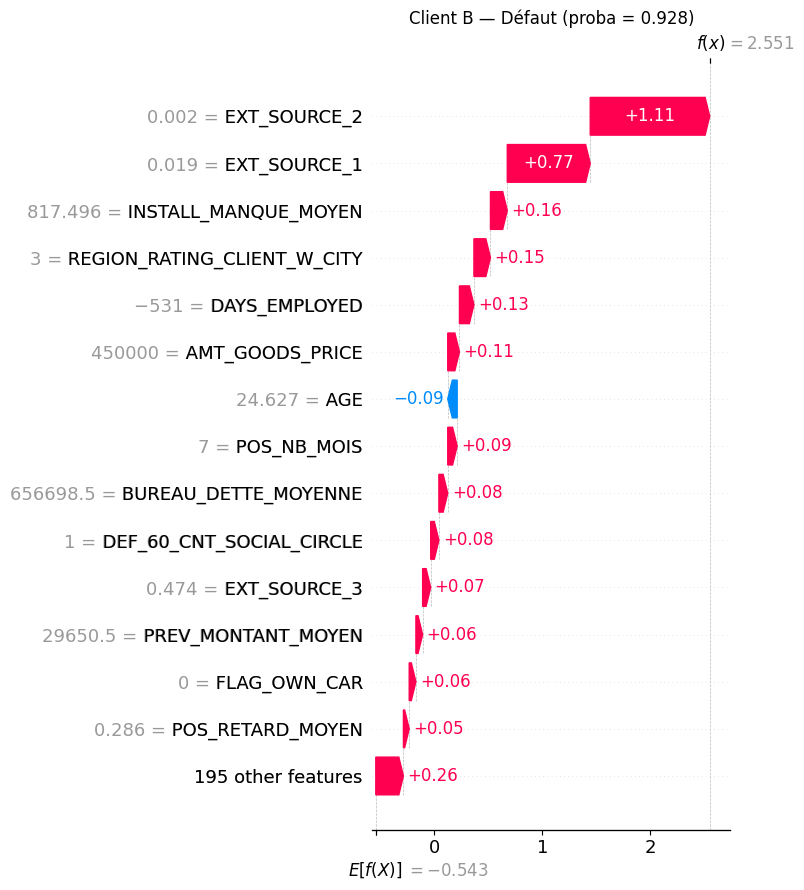

In [10]:
print("=== Client B — Défaut ===")
plt.figure()
shap.waterfall_plot(exp_defaut, max_display=15, show=False)
plt.title(f"Client B — Défaut (proba = {X_sample_eval.loc[idx_defaut, 'proba_defaut']:.3f})")
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/shap_waterfall_defaut.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse Client B (proba = 0.928) :** `EXT_SOURCE_2 = 0.002` (score quasi nul) est le facteur le plus aggravant avec +1.11 — à comparer aux 0.734 du client A. 

`EXT_SOURCE_1 = 0.019` ajoute +0.77. Ces deux features seules font passer la prédiction bien au-dessus de la valeur de base. 

`INSTALL_MANQUE_MOYEN = 817` (retards importants sur crédits passés) et `DAYS_EMPLOYED = -531` (≈ 1.5 ans d'ancienneté seulement, contre 35 ans pour le client A) aggravent encore. 

La seule contribution protectrice est `AGE = 24.6` (-0.09), marginale. 

Au total, f(x) = 2.551 en log-odds → proba défaut très élevée.

## 6. Logging des artefacts SHAP dans MLflow

In [11]:
mlflow.set_experiment("scoring-credit")

with mlflow.start_run(run_name="explicabilite_shap"):

    for fname in ['feature_importance_lgbm.png', 'shap_importance_globale.png',
                  'shap_beeswarm.png', 'shap_waterfall_bon.png',
                  'shap_waterfall_defaut.png']:
        mlflow.log_artifact(f'{SHAP_DIR}/{fname}', artifact_path='shap')

    mlflow.log_param("n_clients_shap", len(X_sample))

    run_id = mlflow.active_run().info.run_id

print(f"Run MLflow : {run_id}")
print(f"Artefacts loggés depuis {SHAP_DIR}/")

Run MLflow : f9eb10ceecf54fe898cdd915f16103b2
Artefacts loggés depuis ../outputs/shap/


## 6. Conclusion

**Analyse :**

- `EXT_SOURCE_2/3` dominent les prédictions — cohérent avec l'EDA
- Le beeswarm confirme la logique : bon score externe → risque faible, mauvais score → risque élevé
- Le waterfall permet d'expliquer chaque décision individuellement — utile pour justifier un refus de crédit
- Les artefacts sont versionnés dans MLflow pour traçabilité